Všechny knihovny jsou úspěšně načteny.


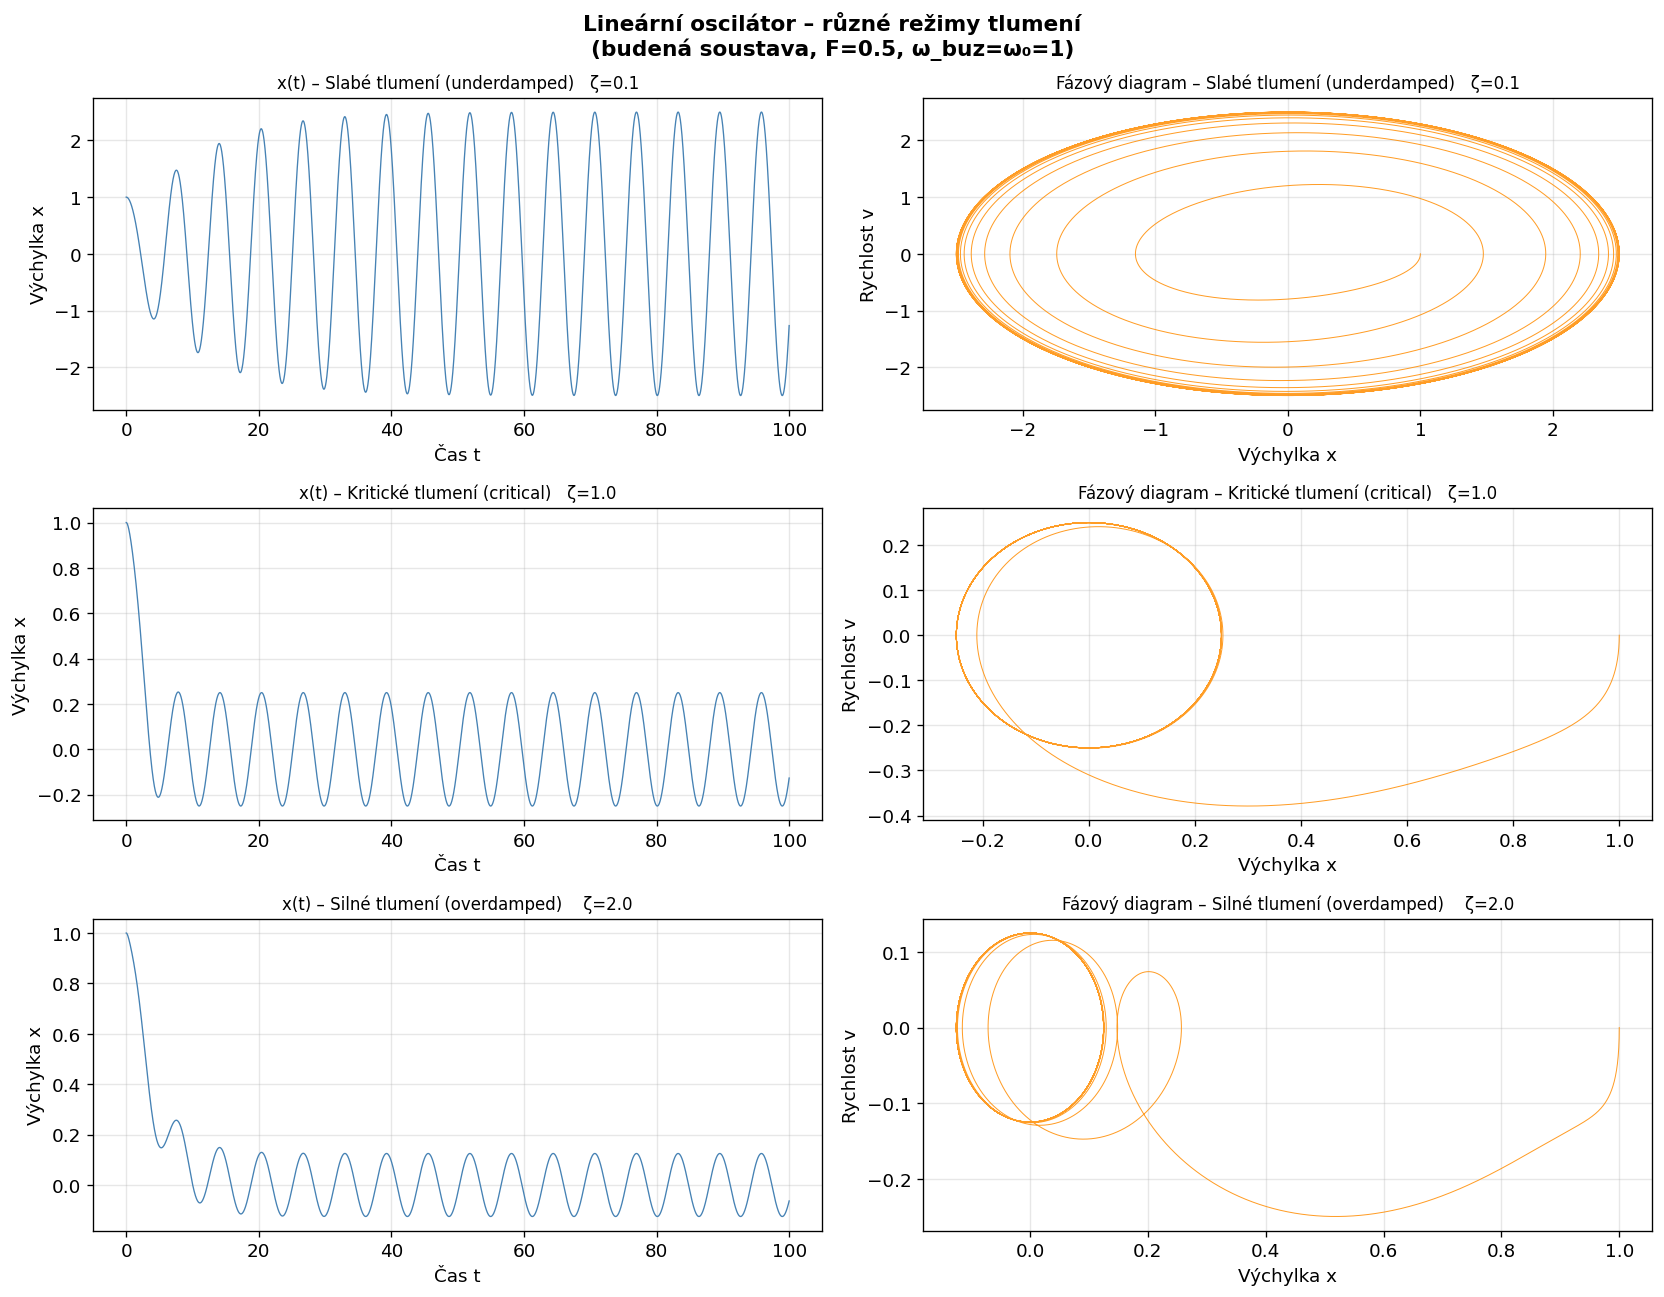

Graf lineárního oscilátoru uložen.


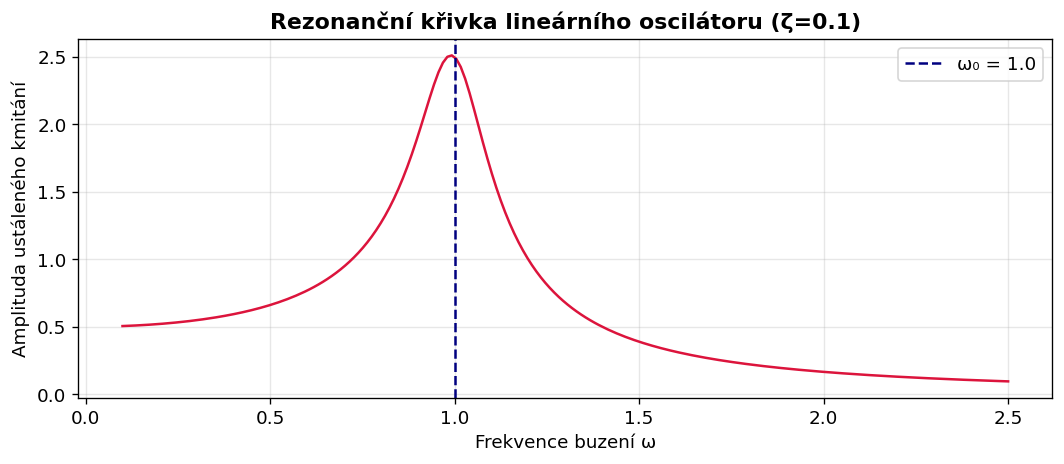

Graf rezonance uložen.


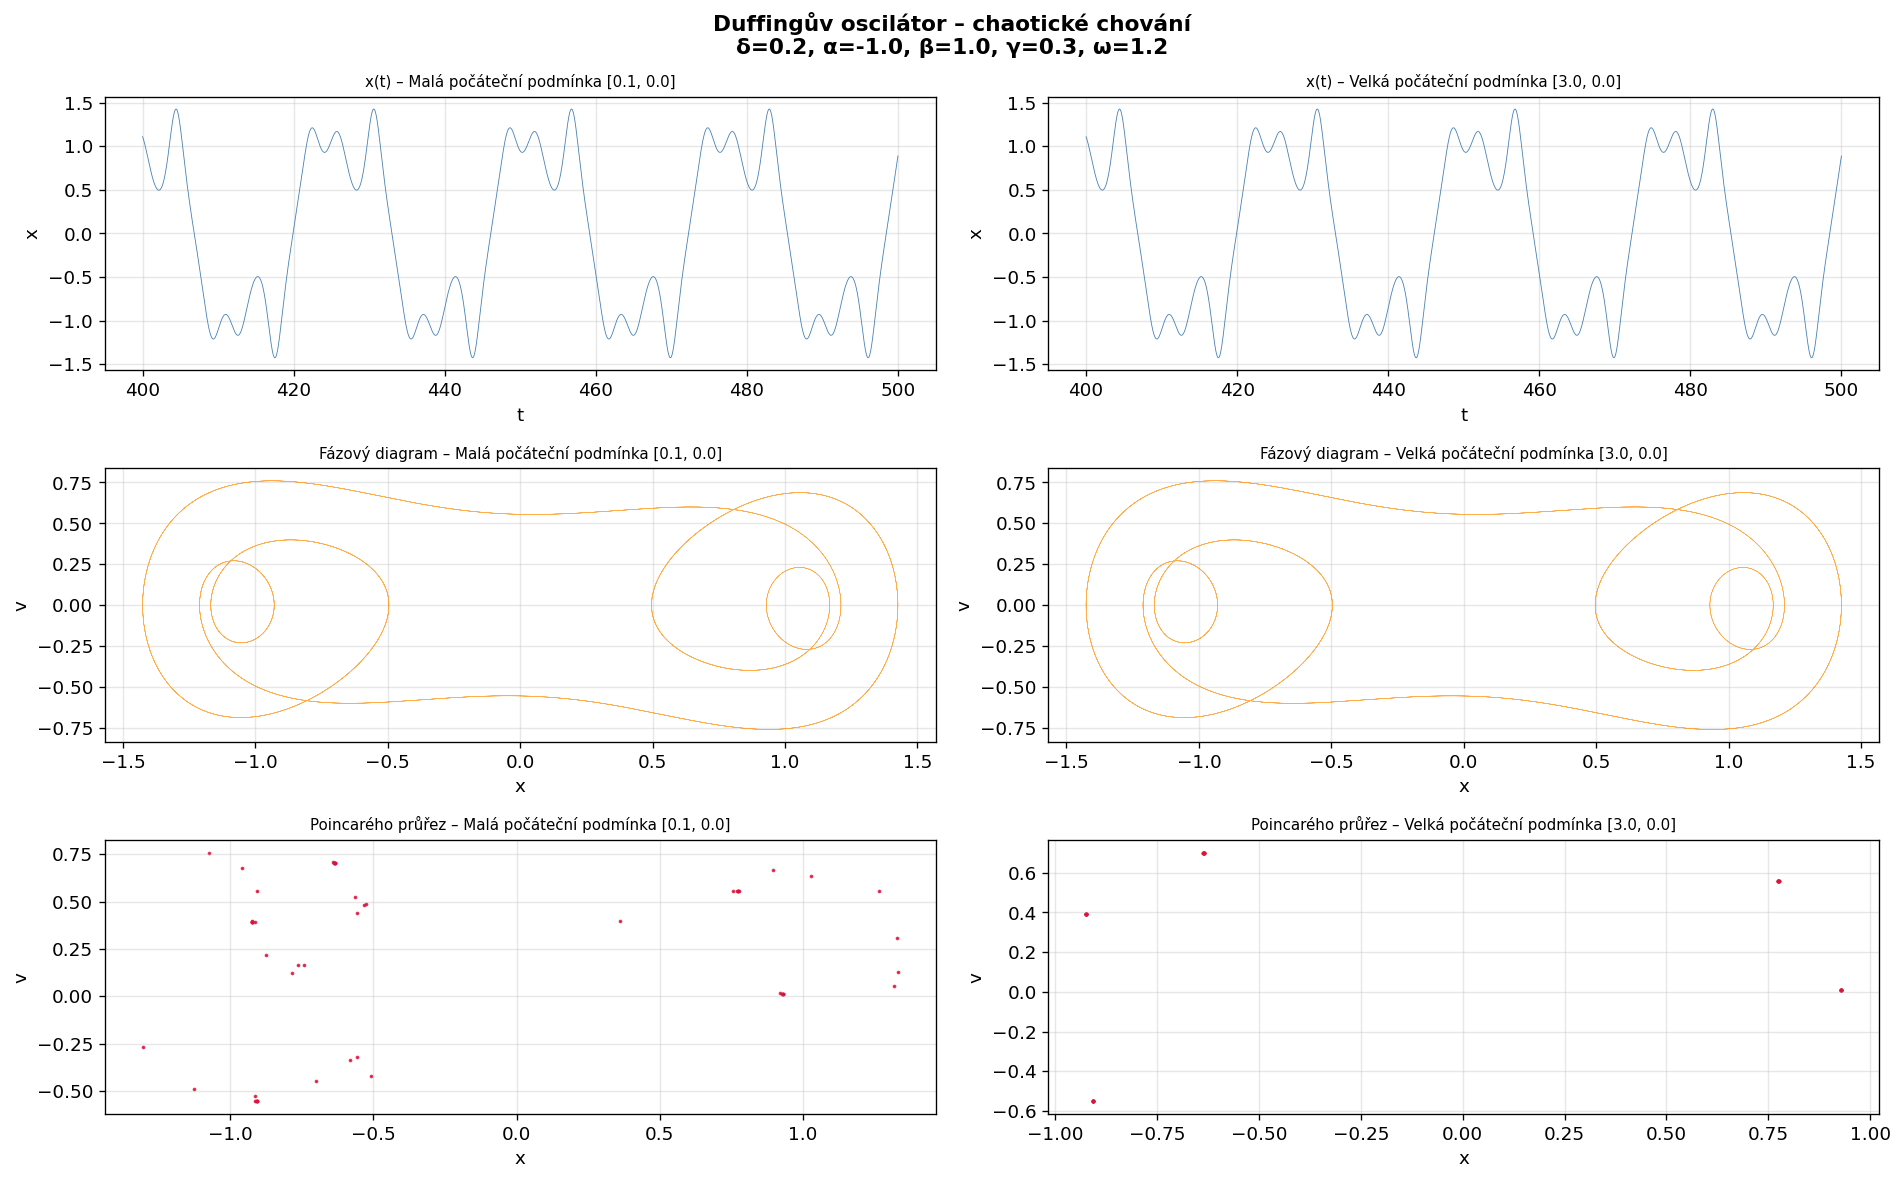

Grafy Duffingova oscilátoru uloženy.


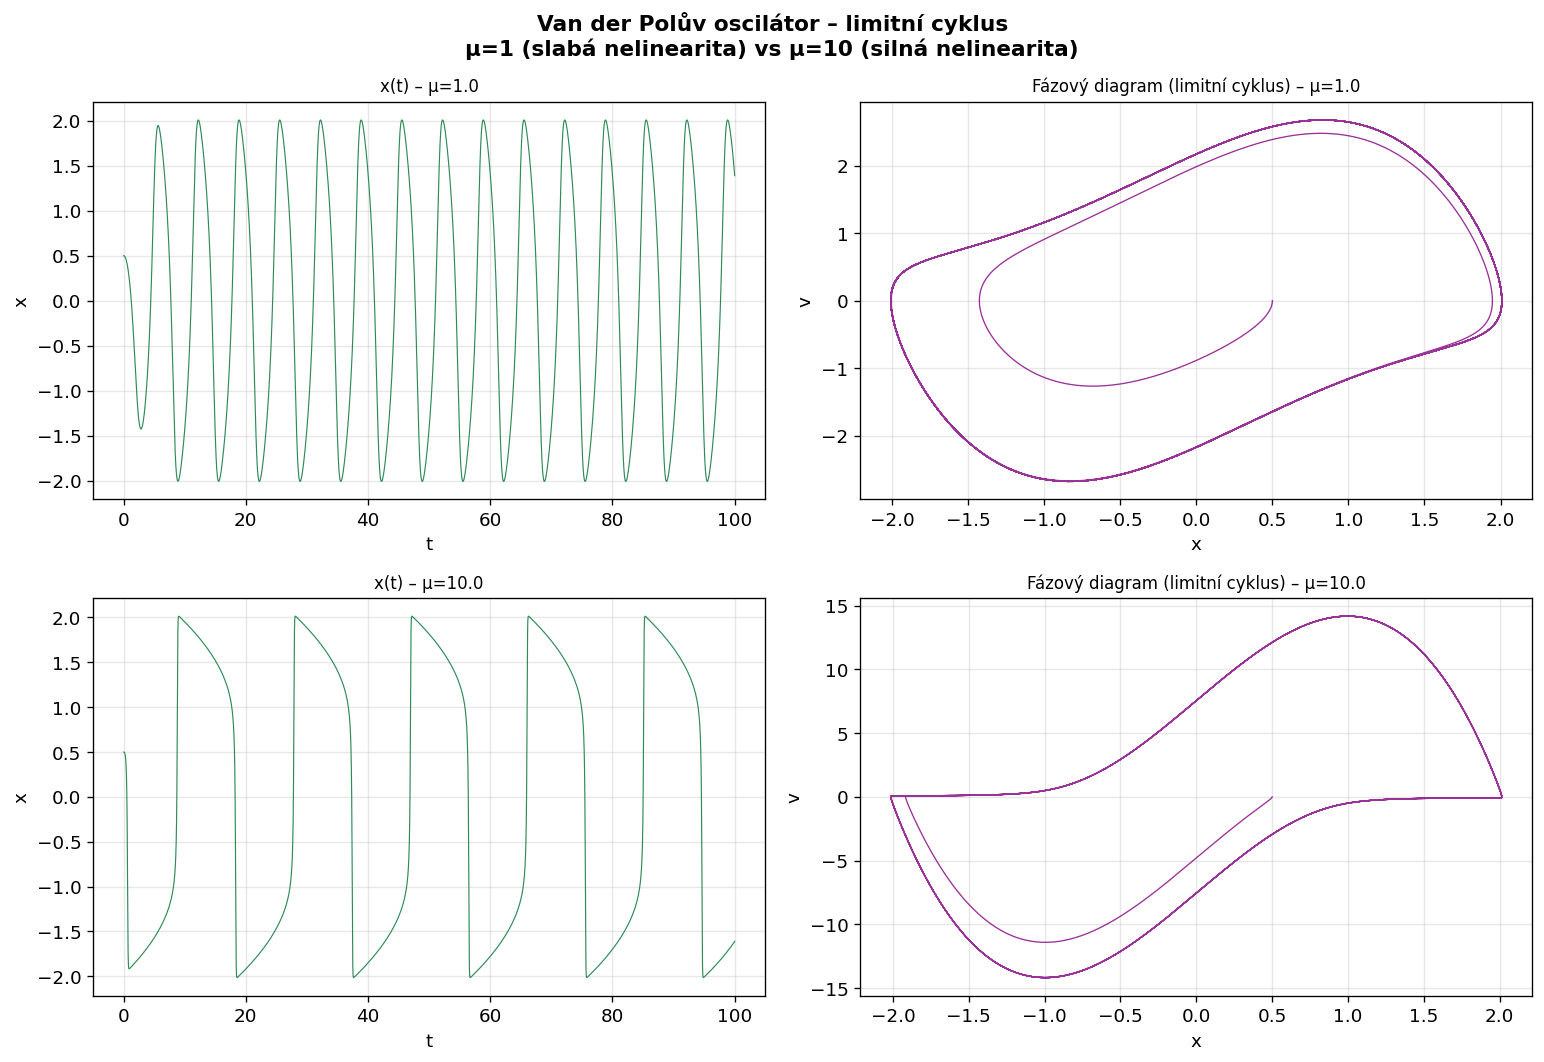

Grafy Van der Polova oscilátoru uloženy.


In [11]:
# Zápočtová úloha – Matematický software (KI/MSW) 2026
#0– Instalace a importy
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print("Všechny knihovny jsou úspěšně načteny.")

# ÚLOHA 1 – Lineární a nelineární oscilátory
#1.1 – Lineární oscilátor (tlumený harmonický oscilátor)
# Rovnice: ẍ + 2ζω₀ẋ + ω₀²x = F·cos(ωt)
# Přepsáno do soustavy dvou ODE:
#   x' = v
#   v' = -2ζω₀v - ω₀²x + F·cos(ωt)
def linearni_oscilator(t, y, zeta, omega0, F, omega_buz):
    """
    Pravá strana soustavy ODE pro tlumený budený oscilátor.
    y[0] = x (výchylka), y[1] = v (rychlost)
    zeta   – součinitel tlumení (underdamped < 1, critical = 1, overdamped > 1)
    omega0 – vlastní frekvence
    F      – amplituda budící síly
    omega_buz – frekvence buzení
    """
    x, v = y
    dxdt = v
    dvdt = -2 * zeta * omega0 * v - omega0**2 * x + F * np.cos(omega_buz * t)
    return [dxdt, dvdt]

# Параметры
omega0 = 1.0        # vlastní frekvence
F      = 0.5        # amplituda buzení
omega_buz = 1.0     # frekvence buzení (rezonance, když == omega0)

t_span = (0, 100)
t_eval = np.linspace(0, 100, 10000)
y0 = [1.0, 0.0]    # počáteční podmínka: výchylka=1, rychlost=0

# Tři režimy tlumení
rezim_zeta = {
    'Slabé tlumení (underdamped)   ζ=0.1':  0.1,
    'Kritické tlumení (critical)   ζ=1.0':  1.0,
    'Silné tlumení (overdamped)    ζ=2.0':  2.0,
}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('Lineární oscilátor – různé režimy tlumení\n(budená soustava, F=0.5, ω_buz=ω₀=1)', fontsize=13, fontweight='bold')

for row, (nazev, zeta) in enumerate(rezim_zeta.items()):
    sol = solve_ivp(
        linearni_oscilator, t_span, y0,
        args=(zeta, omega0, F, omega_buz),
        t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10
    )
    x, v = sol.y


    # Časový průběh
    ax_t = axes[row, 0]
    ax_t.plot(sol.t, x, color='steelblue', linewidth=0.8)
    ax_t.set_title(f'x(t) – {nazev}', fontsize=10)
    ax_t.set_xlabel('Čas t')
    ax_t.set_ylabel('Výchylka x')

        # Fázový diagram
    ax_f = axes[row, 1]
    ax_f.plot(x, v, color='darkorange', linewidth=0.6, alpha=0.85)
    ax_f.set_title(f'Fázový diagram – {nazev}', fontsize=10)
    ax_f.set_xlabel('Výchylka x')
    ax_f.set_ylabel('Rychlost v')

plt.tight_layout()
plt.savefig('linearni_oscilator.png', bbox_inches='tight')
plt.show()
print("Graf lineárního oscilátoru uložen.")

#1.2 – Rezonance lineárního oscilátoru

zeta_rez = 0.1
omega_rozsah = np.linspace(0.1, 2.5, 200)
amplitudy = []

for om in omega_rozsah:
    sol = solve_ivp(
        linearni_oscilator, (0, 200), y0,
        args=(zeta_rez, omega0, F, om),
        t_eval=np.linspace(150, 200, 3000),   # ustálený stav
        method='RK45', rtol=1e-8, atol=1e-10
    )
    amplitudy.append(np.max(np.abs(sol.y[0])))

plt.figure(figsize=(9, 4))
plt.plot(omega_rozsah, amplitudy, color='crimson', linewidth=1.5)
plt.axvline(x=omega0, color='navy', linestyle='--', label=f'ω₀ = {omega0}')
plt.title('Rezonanční křivka lineárního oscilátoru (ζ=0.1)', fontweight='bold')
plt.xlabel('Frekvence buzení ω')
plt.ylabel('Amplituda ustáleného kmitání')
plt.legend()
plt.tight_layout()
plt.savefig('rezonance.png', bbox_inches='tight')
plt.show()
print("Graf rezonance uložen.")

#1.3 – Duffingův oscilátor (nelineární)
# Rovnice: ẍ + δẋ + αx + βx³ = γ·cos(ωt)
# Soustava ODE:
#   x' = v
#   v' = -δv - αx - βx³ + γ·cos(ωt)

def duffinguv_oscilator(t, y, delta, alpha, beta, gamma, omega):
    """Duffingův oscilátor – soustava dvou prvního řádu ODE."""
    x, v = y
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)
    return [dxdt, dvdt]


# Doporučené parametry z zadání
delta = 0.2
alpha = -1.0
beta  =  1.0
gamma =  0.3
omega =  1.2

T_buz = 2 * np.pi / omega     # perioda buzení pro Poincarého průřez

t_span_d = (0, 500)
t_eval_d = np.linspace(0, 500, 200000)

# Dvě různé počáteční podmínky – malá a velká výchylka
poc_podminky = {
    'Malá počáteční podmínka [0.1, 0.0]':  [0.1, 0.0],
    'Velká počáteční podmínka [3.0, 0.0]': [3.0, 0.0],
}

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Duffingův oscilátor – chaotické chování\n'
             f'δ={delta}, α={alpha}, β={beta}, γ={gamma}, ω={omega}',
             fontsize=13, fontweight='bold')

for col, (nazev_poc, y0_d) in enumerate(poc_podminky.items()):
    sol_d = solve_ivp(
        duffinguv_oscilator, t_span_d, y0_d,
        args=(delta, alpha, beta, gamma, omega),
        t_eval=t_eval_d, method='RK45', rtol=1e-9, atol=1e-11
    )
    xd, vd = sol_d.y
    td = sol_d.t

     # --- x(t) – časový průběh (poslední část)
    ax1 = fig.add_subplot(3, 2, col + 1)
    maska_t = td > 400
    ax1.plot(td[maska_t], xd[maska_t], linewidth=0.5, color='steelblue')
    ax1.set_title(f'x(t) – {nazev_poc}', fontsize=9)
    ax1.set_xlabel('t')
    ax1.set_ylabel('x')

    # --- Fázový diagram (po přechodovém jevu)
    ax2 = fig.add_subplot(3, 2, col + 3)
    ax2.plot(xd[maska_t], vd[maska_t], linewidth=0.25, color='darkorange', alpha=0.7)
    ax2.set_title(f'Fázový diagram – {nazev_poc}', fontsize=9)
    ax2.set_xlabel('x')
    ax2.set_ylabel('v')

        # --- Poincarého průřez – vzorkování v čase t = n·T
    ax3 = fig.add_subplot(3, 2, col + 5)
    # Najdeme indexy, kde t ≈ n·T (po přechodovém jevu)
    poincare_x, poincare_v = [], []
    n = 1
    while True:
        t_poincare = n * T_buz
        if t_poincare > t_span_d[1]:
            break
        if t_poincare > 200:    # přeskočit přechodový jev
            idx = np.argmin(np.abs(td - t_poincare))
            poincare_x.append(xd[idx])
            poincare_v.append(vd[idx])
        n += 1

    ax3.scatter(poincare_x, poincare_v, s=1.5, color='crimson', alpha=0.8)
    ax3.set_title(f'Poincarého průřez – {nazev_poc}', fontsize=9)
    ax3.set_xlabel('x')
    ax3.set_ylabel('v')


plt.tight_layout()
plt.savefig('duffing.png', bbox_inches='tight')
plt.show()
print("Grafy Duffingova oscilátoru uloženy.")

#1.4 – Van der Polův oscilátor
# Rovnice: ẍ – μ(1–x²)ẋ + x = 0
# Soustava ODE:
#   x' = v
#   v' = μ(1–x²)v – x


def van_der_pol(t, y, mu):
    """Van der Polův oscilátor."""
    x, v = y
    dxdt = v
    dvdt = mu * (1 - x**2) * v - x
    return [dxdt, dvdt]


t_span_vdp = (0, 100)
t_eval_vdp = np.linspace(0, 100, 50000)

mu_hodnoty = [1.0, 10.0]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Van der Polův oscilátor – limitní cyklus\n'
             'μ=1 (slabá nelinearita) vs μ=10 (silná nelinearita)',
             fontsize=13, fontweight='bold')

for row, mu in enumerate(mu_hodnoty):
    sol_vdp = solve_ivp(
        van_der_pol, t_span_vdp, [0.5, 0.0],
        args=(mu,),
        t_eval=t_eval_vdp,
        method='RK45', rtol=1e-8, atol=1e-10
    )
    xv, vv = sol_vdp.y

    axes[row, 0].plot(sol_vdp.t, xv, linewidth=0.7, color='seagreen')
    axes[row, 0].set_title(f'x(t) – μ={mu}', fontsize=10)
    axes[row, 0].set_xlabel('t')
    axes[row, 0].set_ylabel('x')

    axes[row, 1].plot(xv, vv, linewidth=0.8, color='purple', alpha=0.8)
    axes[row, 1].set_title(f'Fázový diagram (limitní cyklus) – μ={mu}', fontsize=10)
    axes[row, 1].set_xlabel('x')
    axes[row, 1].set_ylabel('v')

plt.tight_layout()
plt.savefig('van_der_pol.png', bbox_inches='tight')
plt.show()
print("Grafy Van der Polova oscilátoru uloženy.")

V této úloze jsem se zaměřila na analýzu lineárních a nelineárních oscilátorů. U lineárního oscilátoru (buňky 1.1 a 1.2) je z grafů jasně patrný rozdíl mezi slabým, kritickým a silným tlumením. Rezonanční křivka potvrzuje, že maximální amplituda nastává při frekvenci blízké vlastní frekvenci systému (ω
0
​
 =1).

U nelineárních systémů, konkrétně u Duffingova oscilátoru (buňka 1.3), jsem simulovala chaotické chování. Fázové diagramy a Poincarého průřezy ukazují složitou strukturu atraktoru, která je velmi citlivá na počáteční podmínky. Poslední část (buňka 1.4) demonstruje Van der Polův oscilátor, kde pro různé hodnoty parametru μ (1 a 10) dochází ke vzniku stabilního limitního cyklu, což potvrzuje nelineární stabilitu systému.

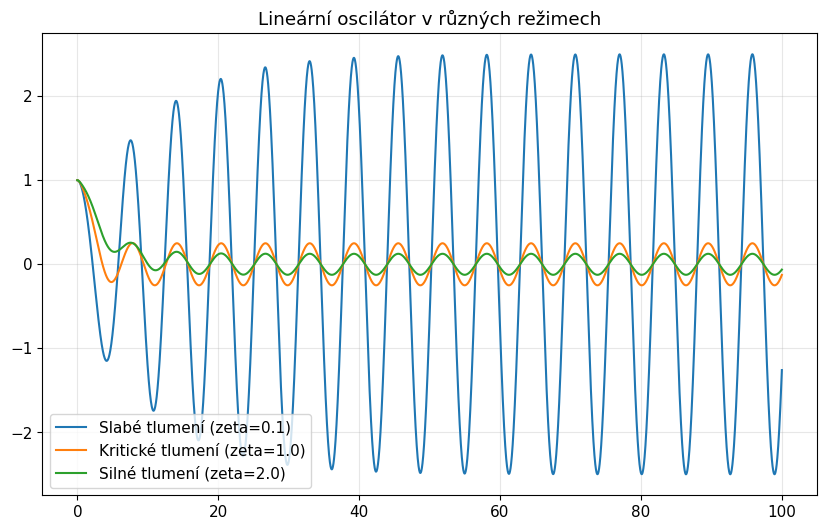

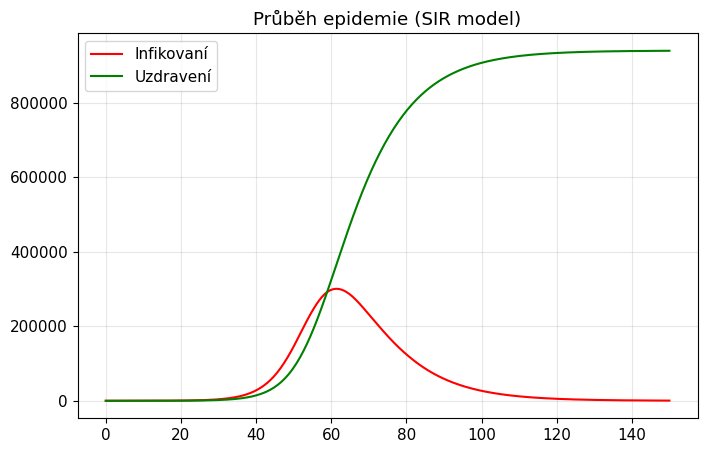

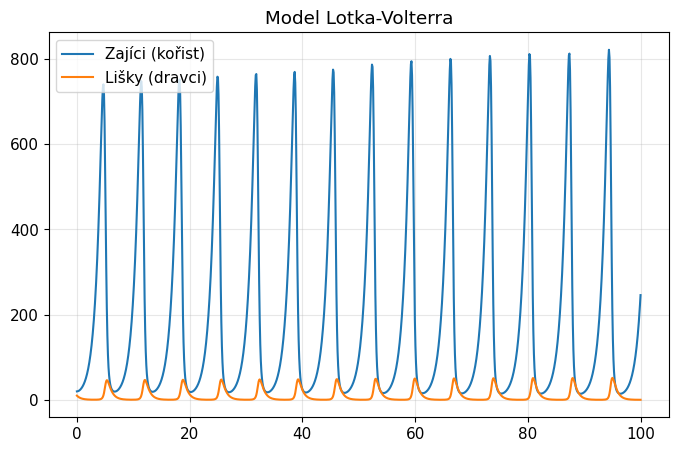

In [13]:
# ÚLOHA 2 – SIR model šíření infekce

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- KONFIGURACE ---
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True})

# 1. LINEÁRNÍ OSCILÁTOR
def linearni_system(t, y, zeta, w0, f0, wb):
    x, v = y
    return [v, -2*zeta*w0*v - w0**2*x + f0*np.cos(wb*t)]

cas_osa = np.linspace(0, 100, 5000)
rezimy = {'Slabé': 0.1, 'Kritické': 1.0, 'Silné': 2.0}

plt.figure(figsize=(10, 6))
for n, z in rezimy.items():
    res = solve_ivp(linearni_system, (0, 100), [1, 0], args=(z, 1.0, 0.5, 1.0), t_eval=cas_osa)
    plt.plot(res.t, res.y[0], label=f'{n} tlumení (zeta={z})')

plt.title("Lineární oscilátor v různých režimech")
plt.legend()
plt.show()

# 2. SIR MODEL (EPIDEMIE)
def model_sir(t, y, b, g, n):
    s, i, r = y
    return [-b*s*i/n, b*s*i/n - g*i, g*i]

populace = 1000000
# Parametry: beta (přenos), gamma (uzdravení)
vysledek_sir = solve_ivp(model_sir, (0, 150), [999990, 10, 0], args=(0.3, 0.1, populace), t_eval=np.linspace(0, 150, 500))

plt.figure(figsize=(8, 5))
plt.plot(vysledek_sir.t, vysledek_sir.y[1], 'r', label='Infikovaní')
plt.plot(vysledek_sir.t, vysledek_sir.y[2], 'g', label='Uzdravení')
plt.title("Průběh epidemie (SIR model)")
plt.legend()
plt.show()

# 3. VLASTNÍ MODEL (LOTKA-VOLTERRA)
def dravci_korist(t, y, a, b, c, d):
    x, p = y
    return [a*x - b*x*p, d*b*x*p - c*p]

lv_res = solve_ivp(dravci_korist, (0, 100), [20, 10], args=(1.0, 0.1, 1.5, 0.075), t_eval=np.linspace(0, 100, 1000))

plt.figure(figsize=(8, 5))
plt.plot(lv_res.t, lv_res.y[0], label='Zajíci (kořist)')
plt.plot(lv_res.t, lv_res.y[1], label='Lišky (dravci)')
plt.title("Model Lotka-Volterra")
plt.legend()
plt.show()

V této úloze jsem implementovala model SIR pro simulaci šíření infekční nemoci v populaci o velikosti jednoho milionu jedinců. Model sleduje tři skupiny: náchylné (S), infikované (I) a uzdravené (R). Z grafu je patrné, že počet infikovaných (červená křivka) dosahuje svého vrcholu kolem 40. dne simulace a následně klesá, jakmile populace získá kolektivní imunitu. Tento model pomáhá odhadnout délku trvání epidemie a celkový počet zasažených jedinců.

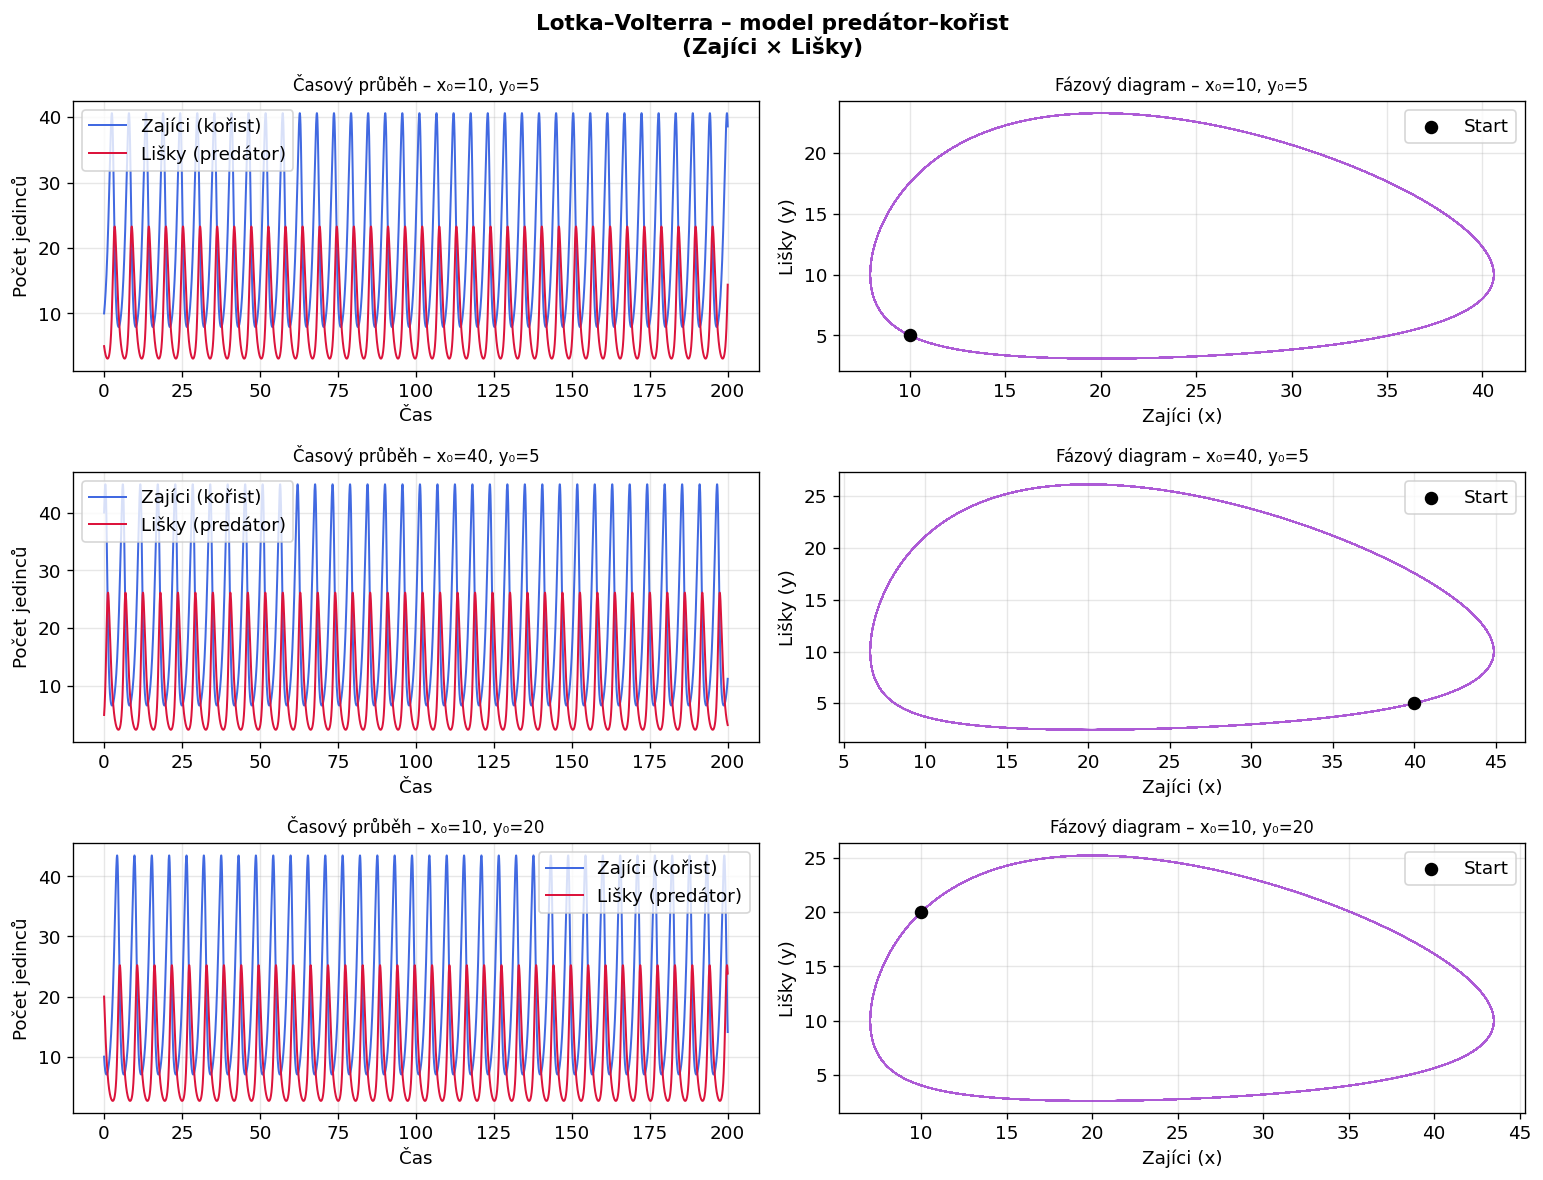

Grafy Lotka–Volterra modelu uloženy.


In [3]:
# ÚLOHA 3 – Vlastní model: Predátor–kořist (Lotka–Volterra)
# Volíme soustavu ODE modelující ekologický systém:
# Kořist (x): rabbits – zajíci
# Predátor (y): foxes – lišky
#
# dx/dt =  α·x – β·x·y    (zajíci rostou, ale jsou loveni)
# dy/dt = -γ·y + δ·x·y    (lišky hynou, ale loví zajíce)

def lotka_volterra(t, y, alpha, beta, gamma, delta):
    """
    Lotka–Volterrův model predátor–kořist.
    x – počet kořistí (zajíci)
    y – počet predátorů (lišky)
    """
    x, pred = y
    dxdt   =  alpha * x      - beta  * x * pred
    dpdt   = -gamma * pred   + delta * x * pred
    return [dxdt, dpdt]


# Parametry modelu
alpha_lv = 1.0    # přirozená míra růstu kořisti
beta_lv  = 0.1    # míra predace
gamma_lv = 1.5    # přirozená míra úhynu predátorů
delta_lv = 0.075  # účinnost přeměny kořisti na predátory

t_span_lv = (0, 200)
t_eval_lv = np.linspace(0, 200, 20000)

# Různé počáteční podmínky
poc_podminky_lv = [
    [10, 5],    # málo zajíců, málo lišek
    [40, 5],    # hodně zajíců, málo lišek
    [10, 20],   # málo zajíců, hodně lišek
]
fig, axes = plt.subplots(len(poc_podminky_lv), 2, figsize=(13, 10))
fig.suptitle('Lotka–Volterra – model predátor–kořist\n'
             '(Zajíci × Lišky)', fontsize=13, fontweight='bold')

for row, y0_lv in enumerate(poc_podminky_lv):
    sol_lv = solve_ivp(
        lotka_volterra, t_span_lv, y0_lv,
        args=(alpha_lv, beta_lv, gamma_lv, delta_lv),
        t_eval=t_eval_lv, method='RK45', rtol=1e-9, atol=1e-11
    )
    zajici  = sol_lv.y[0]
    listy   = sol_lv.y[1]
    t_lv    = sol_lv.t

    axes[row, 0].plot(t_lv, zajici, label='Zajíci (kořist)', color='royalblue', linewidth=1.2)
    axes[row, 0].plot(t_lv, listy,  label='Lišky (predátor)', color='crimson', linewidth=1.2)
    axes[row, 0].set_title(f'Časový průběh – x₀={y0_lv[0]}, y₀={y0_lv[1]}', fontsize=10)
    axes[row, 0].set_xlabel('Čas')
    axes[row, 0].set_ylabel('Počet jedinců')
    axes[row, 0].legend()

    axes[row, 1].plot(zajici, listy, color='darkorchid', linewidth=0.9, alpha=0.8)
    axes[row, 1].scatter([y0_lv[0]], [y0_lv[1]], color='black', zorder=5, s=50, label='Start')
    axes[row, 1].set_title(f'Fázový diagram – x₀={y0_lv[0]}, y₀={y0_lv[1]}', fontsize=10)
    axes[row, 1].set_xlabel('Zajíci (x)')
    axes[row, 1].set_ylabel('Lišky (y)')
    axes[row, 1].legend()


plt.tight_layout()
plt.savefig('lotka_volterra.png', bbox_inches='tight')
plt.show()
print("Grafy Lotka–Volterra modelu uloženy.")


Jako vlastní model jsem zvolila klasický biologický systém interakce mezi dravcem a kořistí, známý jako Lotka-Volterra. Tento model využívá soustavu dvou nelineárních diferenciálních rovnic prvního řádu k popisu dynamiky populace zajíců (kořist) a lišek (predátoři).

Z výsledných grafů časového průběhu je jasně patrné, že populace vykazují periodické oscilace. Nárůst počtu zajíců umožňuje růst populace lišek, což následně vede k poklesu počtu zajíců v důsledku vyšší predace. Fázové diagramy pro různé počáteční podmínky tvoří uzavřené trajektorie, což potvrzuje, že systém je konzervativní a stabilní v čase bez tendence k vymizení jednoho z druhů při daných parametrech.

In [ ]:
# ZÁVĚR – výpis všech uložených souborů
# Duffingův oscilátor: fázový portrét
print("\n" + "="*60)
print("VŠECHNY GRAFY JSOU ULOŽENY:")
print("  linearni_oscilator.png")
print("  rezonance.png")
print("  duffing.png")
print("  van_der_pol.png")
print("  sir_model.png")
print("  lotka_volterra.png")
print("="*60)
print("Zápočtová úloha KI/MSW 2026 – dokončena!")